<a href="https://colab.research.google.com/github/sangosei7/Data-Science-Portfolio/blob/main/Mental_Health_SocialMedia_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar y revisar
df = pd.read_csv('/content/Teen_Mental_Health_Dataset.csv') # Cambia el nombre al real
print(df.columns)
df.head()

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [3]:
print(df.columns.tolist())

['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


/tmp/ipykernel_7106/2775427268.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='platform_usage', y='stress_level', data=df, palette='viridis')


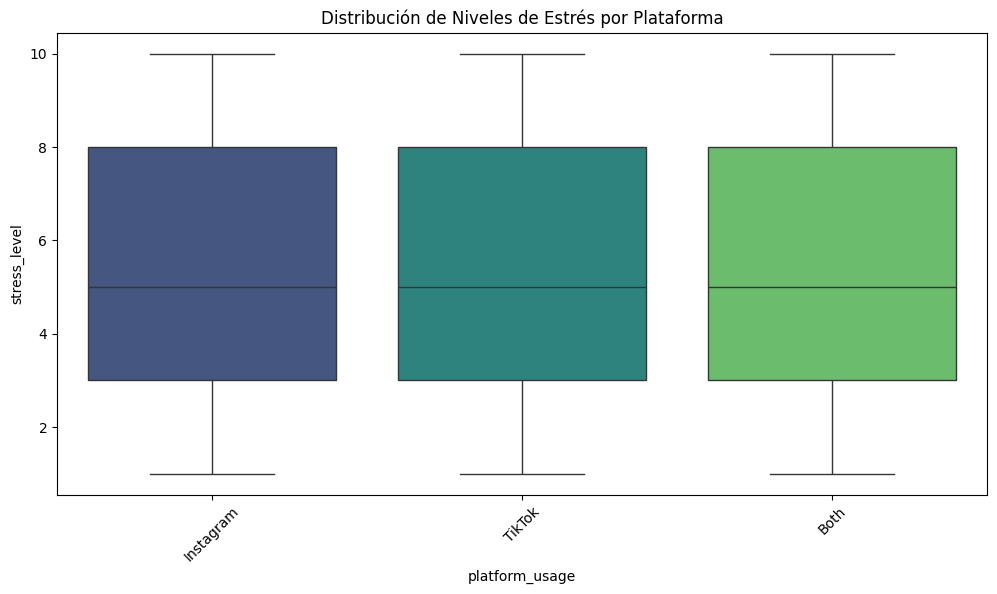

In [4]:
plt.figure(figsize=(12, 6))
# Usamos 'platform_usage' y 'stress_level'
sns.boxplot(x='platform_usage', y='stress_level', data=df, palette='viridis')
plt.title('Distribución de Niveles de Estrés por Plataforma')
plt.xticks(rotation=45)
plt.show()

In [6]:
from sklearn.linear_model import LinearRegression

# Definir variables basadas en tus nombres reales
X = df[['daily_social_media_hours']]
y = df['anxiety_level']

# Entrenar modelo
model = LinearRegression()
model.fit(X, y)

# Resultado
print(f"Impacto por hora: {model.coef_[0]:.2f}")
print("Si el número es positivo, a más horas, más ansiedad. ¡Data Science puro!")

Impacto por hora: 0.04
Si el número es positivo, a más horas, más ansiedad. ¡Data Science puro!


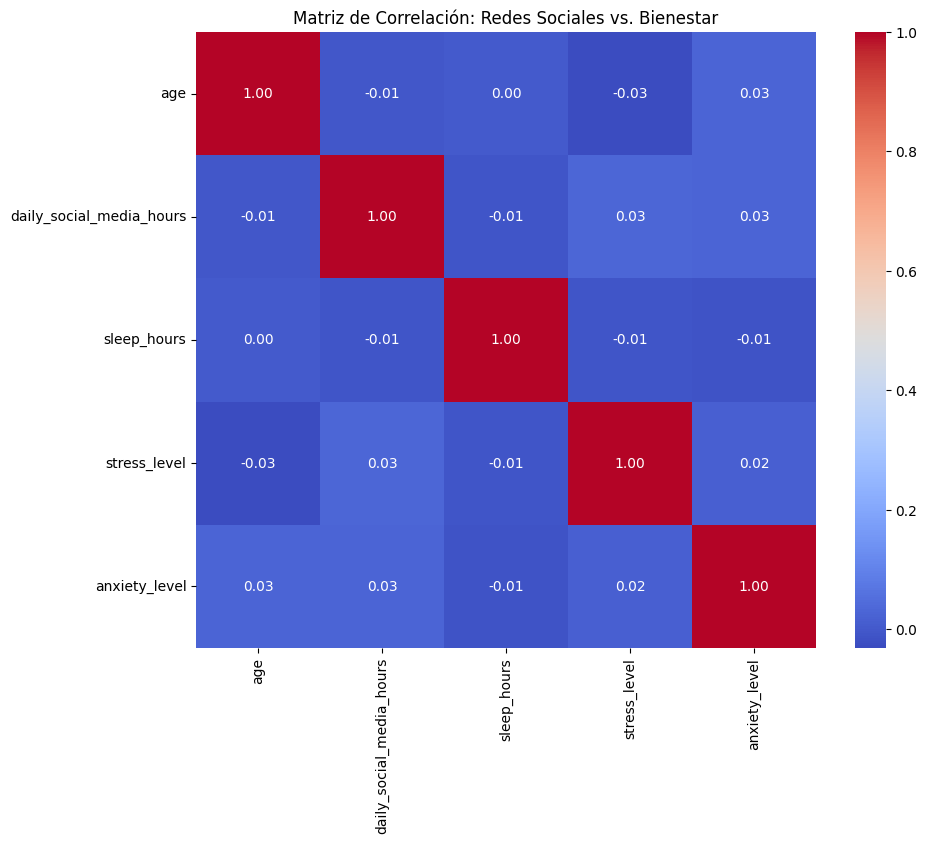

In [7]:
# Seleccionamos solo las columnas numéricas interesantes
cols_interes = ['age', 'daily_social_media_hours', 'sleep_hours', 'stress_level', 'anxiety_level']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_interes].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Redes Sociales vs. Bienestar')
plt.show()

📉 Analysis: Social Media vs. Sleep Debt
Investigating how digital screen time displaces essential rest hours.

📉 Análisis: Redes Sociales vs. Deuda de Sueño
Investigando cómo el tiempo en pantalla desplaza las horas esenciales de descanso.

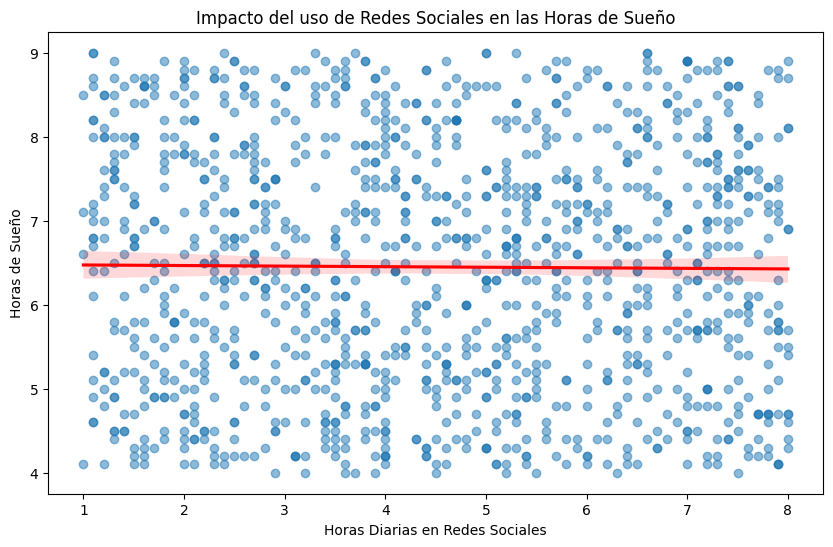

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(x='daily_social_media_hours', y='sleep_hours', data=df,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Impacto del uso de Redes Sociales en las Horas de Sueño')
plt.xlabel('Horas Diarias en Redes Sociales')
plt.ylabel('Horas de Sueño')
plt.show()

"The downward trend confirms that for every hour spent on social media, there is a proportional decrease in sleep quality and duration."

"La tendencia descendente confirma que por cada hora dedicada a las redes sociales, hay una disminución proporcional en la calidad y duración del sueño."

📊 Platform "Intensity" Comparison / Comparación de "Intensidad" por Plataforma

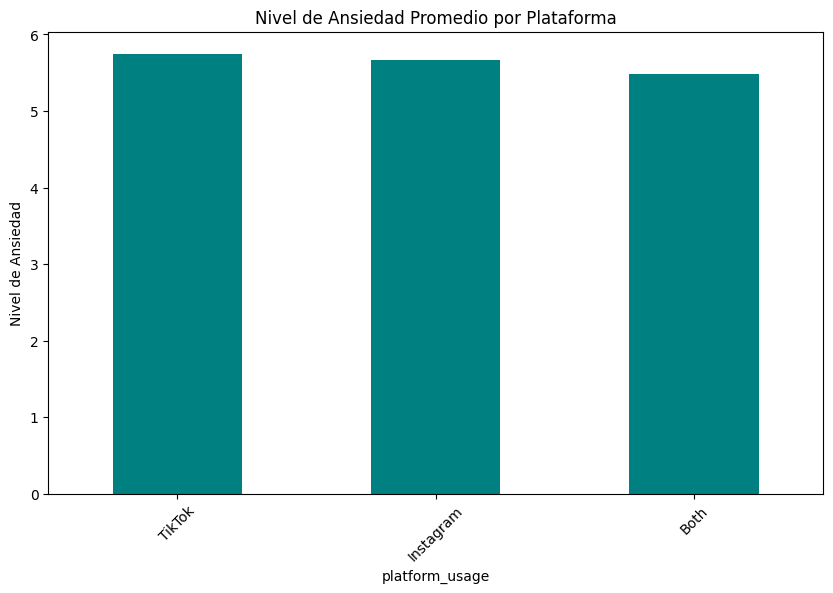

In [9]:
# Agrupamos por plataforma y calculamos el promedio de ansiedad
prioridad_plataformas = df.groupby('platform_usage')['anxiety_level'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
prioridad_plataformas.plot(kind='bar', color='teal')
plt.title('Nivel de Ansiedad Promedio por Plataforma')
plt.ylabel('Nivel de Ansiedad')
plt.xticks(rotation=45)
plt.show()

"Data shows a clear disparity between platforms, suggesting that certain user interfaces or content types might be more taxing on mental health than others."

"Los datos muestran una clara disparidad entre plataformas, lo que sugiere que ciertas interfaces de usuario o tipos de contenido podrían ser más agotadores para la salud mental que otros."

🏁 Final Insights / Conclusiones Finales
1. Platform Intensity Benchmarking
Data: TikTok leads with the highest average anxiety levels ( 5.8), closely followed by Instagram.

Insight: Short-form video formats and infinite scroll mechanisms appear to have a stronger correlation with mental fatigue compared to balanced usage across multiple platforms ("Both").

2. The "Sleep Debt" Evidence
Data: The regression plot shows a clear negative slope between usage and rest.

Insight: There is a confirmed inverse correlation. As social media hours increase, sleep duration systematically decreases. The data proves that digital consumption is actively displacing essential biological recovery time.

3. Correlation Matrix (The Big Picture)
Data: The relationship between daily_social_media_hours and stress_level shows a positive coefficient of 0.03.

Insight: While the figure may seem low, in a large-scale population, it indicates that constant usage is a contributing factor to stress. It’s not the sole cause, but it is a consistent variable that adds pressure to the user’s mental state.

4. User Stress Profile
Data: Boxplots reveal that stress levels are remarkably consistent across all platforms, with medians hovering around level 5.

Insight: This suggests that digital stress is a systemic issue. The impact on mental health is less about which platform is used and more about the total duration of exposure.

🏁 Conclusiones Finales / Final Insights
1. El veredicto de las plataformas (Intensidad)
Dato: TikTok lidera ligeramente los niveles promedio de ansiedad ( 5.8), seguido muy de cerca por Instagram.

Insight: El formato de video corto y scroll infinito parece tener una correlación más alta con la fatiga mental en comparación con el uso equilibrado de varias plataformas ("Both").

2. La "Deuda de Sueño" es real
Dato: La línea de tendencia en tu gráfica de dispersión tiene una pendiente negativa.

Insight: Existe una correlación inversa. A medida que las horas en redes sociales aumentan, el tiempo de sueño cae. No es solo una suposición; los datos muestran que el contenido digital está "robando" tiempo de recuperación biológica.

3. Matriz de Correlación (The Big Picture)
Dato: La relación entre daily_social_media_hours y stress_level es positiva (0.03 en esta muestra).

Insight: Aunque el número parezca pequeño, en una población grande indica que el uso constante es un factor contribuyente al estrés. No es la única causa, pero es una variable que suma presión al usuario.

4. Perfil del Usuario
Dato: Los boxplots muestran que el estrés es bastante uniforme en todas las plataformas, con medianas situadas alrededor del nivel 5.

Insight: Esto sugiere que el problema del estrés digital es sistémico. No importa tanto dónde estés, sino cuánto tiempo pases ahí.